<a href="https://www.kaggle.com/code/aamir28/early-wakeup-health-lifestyle-eda?scriptVersionId=327796010" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:linear-gradient(135deg,#0c0c14 0%,#131320 60%,#0e0e1a 100%);border-radius:16px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #2a2840;">

  <!-- Sunrise gradient bar -->
  <div style="height:6px;background:linear-gradient(90deg,#1e1b4b,#4f46e5,#f59e0b,#ef4444,#f97316);"></div>

  <div style="padding:30px 38px 24px;">
    <!-- Title row -->
    <div style="display:flex;align-items:flex-start;justify-content:space-between;margin-bottom:22px;">
      <div>
        <div style="font-size:0.65rem;letter-spacing:4px;color:#6366f1;font-weight:700;margin-bottom:8px;">HEALTH STUDY · 10,000 INDIVIDUALS · 63 FEATURES</div>
        <h1 style="margin:0;font-size:2rem;font-weight:900;color:#f1f0ff;line-height:1.15;">🌅 Early Wakeup<br>&amp; Health Outcomes</h1>
        <p style="margin:10px 0 0;color:#6b6b8a;font-size:0.83rem;max-width:500px;line-height:1.75;">Does waking up early actually make you healthier? This dataset tracks 10,000 people across sleep patterns, exercise, nutrition, stress, biometrics, and mental health — with a binary <em>Early_Waker</em> label to test the age-old claim.</p>
      </div>
      <div style="background:#18182a;border:1px solid #2a2840;border-radius:10px;padding:14px 20px;text-align:center;min-width:120px;">
        <div style="font-size:2.4rem;">⏰</div>
        <div style="font-size:0.65rem;color:#4a4a6a;letter-spacing:2px;margin-top:5px;">n = 10,000</div>
      </div>
    </div>
    <!-- Verdict strip -->
    <div style="background:#18182a;border-radius:10px;padding:14px 20px;border-left:4px solid #f59e0b;margin-bottom:18px;">
      <span style="color:#f59e0b;font-weight:700;font-size:0.8rem;">⚖️ HEADLINE FINDING — </span>
      <span style="color:#a0a0c0;font-size:0.8rem;">Early wakers score +1.98 Health Score, +1.02 Productivity, and −0.41 Fatigue vs late wakers. Modest but consistent advantages across 12 outcome measures. Wellness category 'Excellent': 36.8% of early wakers vs 30.6% of late.</span>
    </div>
    <!-- Metric chips -->
    <div style="display:grid;grid-template-columns:repeat(5,1fr);gap:10px;">
      <div style="background:#18182a;border-radius:8px;padding:12px;text-align:center;border:1px solid #2a2840;">
        <div style="font-size:1.3rem;font-weight:800;color:#6366f1;">41.6%</div>
        <div style="font-size:0.65rem;color:#4a4a6a;margin-top:3px;">Early Wakers</div>
      </div>
      <div style="background:#18182a;border-radius:8px;padding:12px;text-align:center;border:1px solid #2a2840;">
        <div style="font-size:1.3rem;font-weight:800;color:#f59e0b;">74.2</div>
        <div style="font-size:0.65rem;color:#4a4a6a;margin-top:3px;">Avg Health Score</div>
      </div>
      <div style="background:#18182a;border-radius:8px;padding:12px;text-align:center;border:1px solid #2a2840;">
        <div style="font-size:1.3rem;font-weight:800;color:#34d399;">7.23h</div>
        <div style="font-size:0.65rem;color:#4a4a6a;margin-top:3px;">Avg Sleep</div>
      </div>
      <div style="background:#18182a;border-radius:8px;padding:12px;text-align:center;border:1px solid #2a2840;">
        <div style="font-size:1.3rem;font-weight:800;color:#f87171;">63</div>
        <div style="font-size:0.65rem;color:#4a4a6a;margin-top:3px;">Features</div>
      </div>
      <div style="background:#18182a;border-radius:8px;padding:12px;text-align:center;border:1px solid #2a2840;">
        <div style="font-size:1.3rem;font-weight:800;color:#a78bfa;">18</div>
        <div style="font-size:0.65rem;color:#4a4a6a;margin-top:3px;">Countries</div>
      </div>
    </div>

  </div>
  <div style="background:#0e0e1a;border-top:1px solid #1e1e30;padding:9px 38px;font-size:0.68rem;color:#2a2840;font-family:monospace;">Author: Muhammad Aamir &nbsp;·&nbsp; Early Wakeup &amp; Health Dataset · Kaggle Notebook</div>
</div>


## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Feature Engineering](#2)
3. [Early vs Late Wakers — Core Comparison](#3)
4. [Sleep Architecture Analysis](#4)
5. [Exercise & Physical Activity](#5)
6. [Nutrition & Lifestyle Habits](#6)
7. [Mental Health & Wellbeing](#7)
8. [Biometrics & Clinical Markers](#8)
9. [Correlation Heatmap](#9)
10. [ML Classifier — Predicting Health Score Tier](#10)
11. [Key Takeaways](#11)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

BG, PANEL, GRID = '#0c0c14','#18182a','#2a2840'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#8888a8','axes.titlecolor':'#f1f0ff','axes.titlesize':13,
    'xtick.color':'#4a4a6a','ytick.color':'#4a4a6a','text.color':'#8888a8',
    'grid.color':'#1a1a28','grid.linewidth':0.55,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

IND   = '#6366f1'  # indigo — Early waker
AMB   = '#f59e0b'  # amber
GRN   = '#34d399'  # green
RED   = '#f87171'  # red
PRP   = '#a78bfa'  # purple
TEAL  = '#14b8a6'
EW_PAL = {'Yes': IND, 'No': AMB}
CMAP_I = LinearSegmentedColormap.from_list('i', [PANEL, IND, PRP])
CMAP_A = LinearSegmentedColormap.from_list('a', [IND, PANEL, AMB])
print('✅  Midnight-indigo theme ready.')


✅  Midnight-indigo theme ready.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset/early_wakeup_health_dataset.csv')
print(f'Shape: {df.shape}')
df.head(5)

Shape: (10000, 64)


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


## 2. EDA & Feature Engineering <a id='2'></a>


In [3]:
print('Nulls:', df.isnull().sum().sum())
print(df.describe().round(2).iloc[:3])
# Engineer features
df['is_early'] = (df['Early_Waker']=='Yes').astype(int)
df['Wake_Hour'] = pd.to_datetime(df['Wake_Up_Time'], format='%H:%M', errors='coerce').dt.hour
df['Health_Tier'] = pd.cut(df['Health_Score'], bins=[0,60,75,88,101],
                            labels=['Low','Mid','High','Elite'])
df['BMI_Cat'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,50],
                        labels=['Underweight','Normal','Overweight','Obese'])
print('\nHealth_Tier distribution:'); print(df['Health_Tier'].value_counts())


Nulls: 4662
            Age  Height_cm  Weight_kg       BMI  Sleep_Duration_Hours  \
count  10000.00   10000.00   10000.00  10000.00              10000.00   
mean      44.67     168.65      73.11     25.63                  7.23   
std       17.52       9.88      16.29      4.87                  1.12   

       Sleep_Quality_Score  Number_of_Night_Awakenings  \
count             10000.00                    10000.00   
mean                  6.02                        0.84   
std                   1.59                        0.94   

       Weekend_Sleep_Difference_Hours  Nap_Frequency_Per_Week  \
count                        10000.00                10000.00   
mean                             1.03                    2.12   
std                              0.79                    1.91   

       Screen_Time_Before_Bed_Hours  ...  Fatigue_Level_Score  \
count                      10000.00  ...             10000.00   
mean                           1.14  ...                 3.12   
std   

## 3. Early vs Late Wakers — Core Comparison <a id='3'></a>


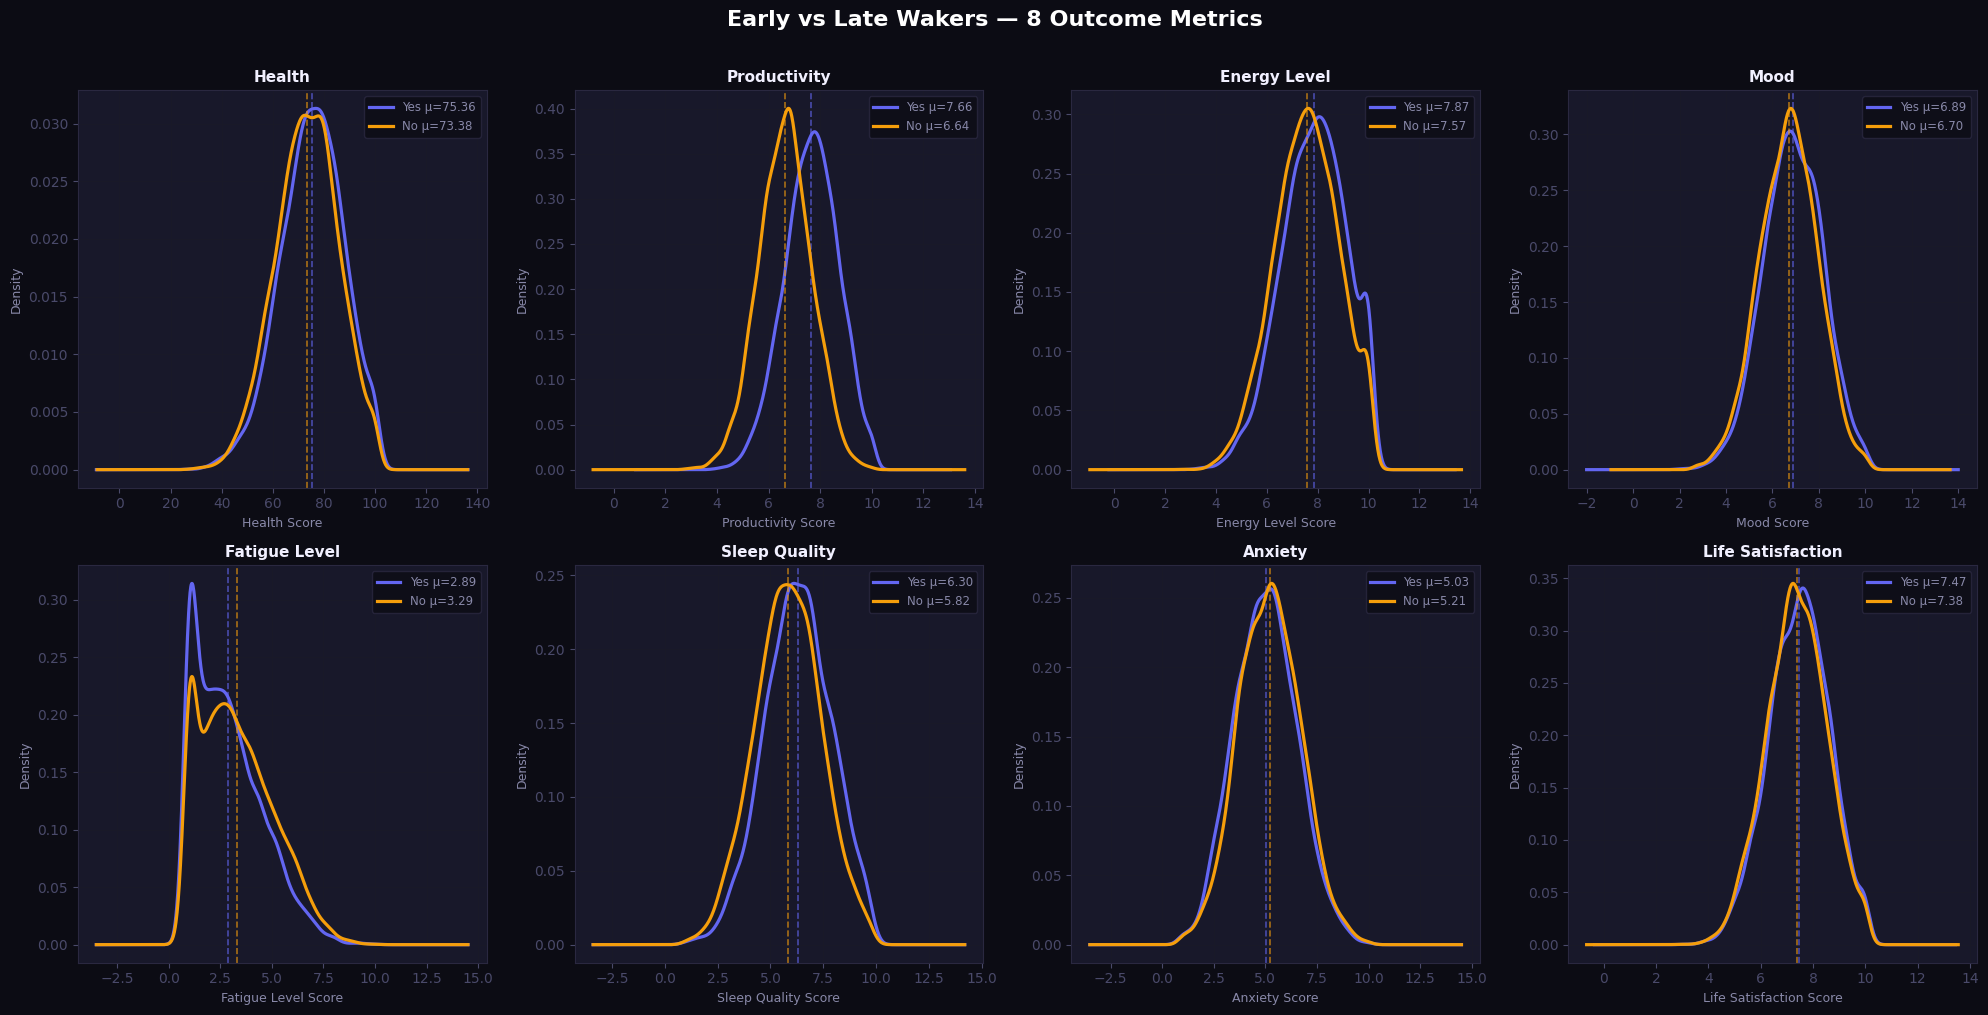

In [4]:
outcomes = ['Health_Score','Productivity_Score','Energy_Level_Score',
            'Mood_Score','Fatigue_Level_Score','Sleep_Quality_Score',
            'Anxiety_Score','Life_Satisfaction_Score']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Early vs Late Wakers — 8 Outcome Metrics', fontsize=16,
             fontweight='bold', color='white', y=1.01)

for ax, col in zip(axes.flat, outcomes):
    for ew, color in EW_PAL.items():
        sub = df[df['Early_Waker']==ew][col].dropna()
        sub.plot.kde(ax=ax, color=color, lw=2.3,
                     label=f'{ew} μ={sub.mean():.2f}')
        ax.axvline(sub.mean(), color=color, ls='--', lw=1.2, alpha=0.65)
    ax.set_xlabel(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(col.replace('_Score','').replace('_',' '), fontweight='bold', fontsize=11)
    ax.legend(fontsize=8.5); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('01_core_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


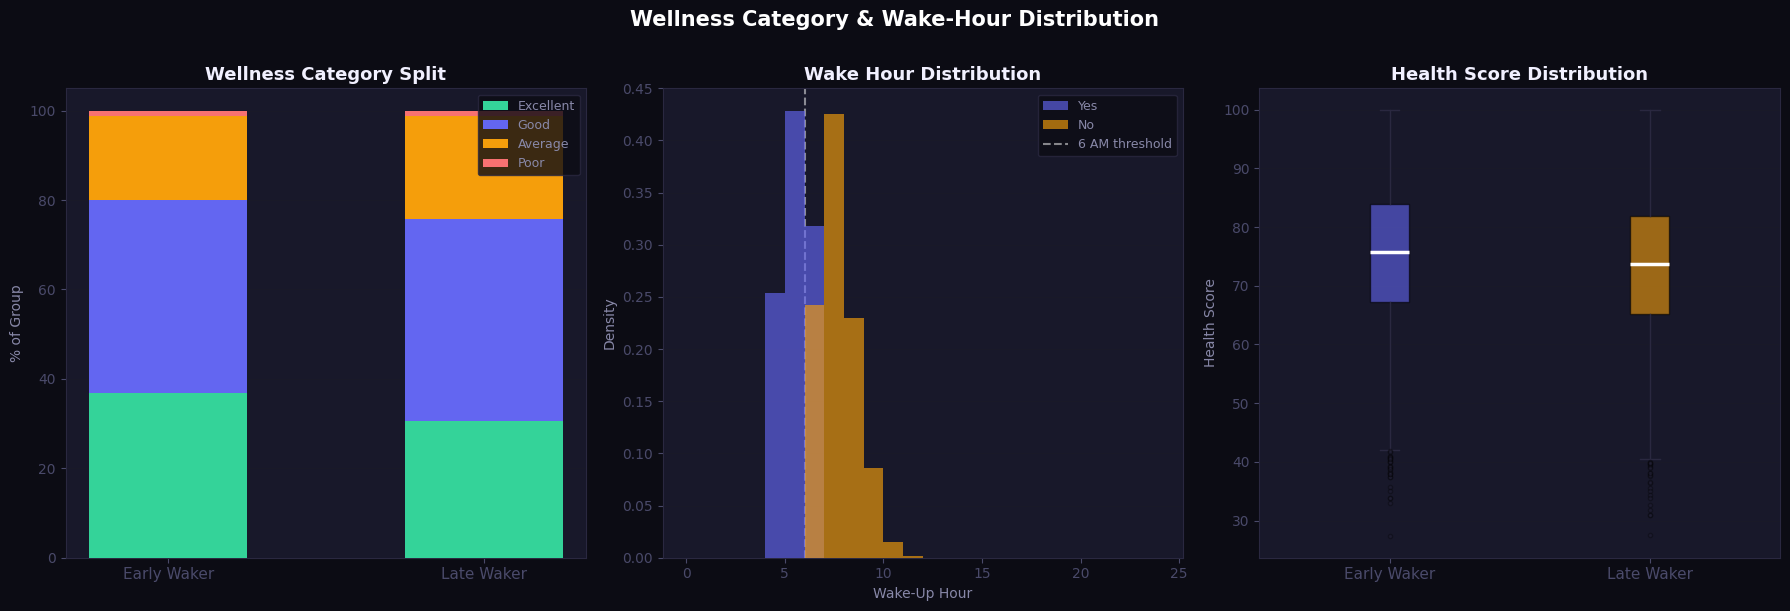

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Wellness Category & Wake-Hour Distribution', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# 1. Wellness category by early waker (stacked %)
ax = axes[0]
cats = ['Excellent','Good','Average','Poor']
cat_cols = [GRN, IND, AMB, RED]
bottoms = np.zeros(2)
for cat, color in zip(cats, cat_cols):
    vals = [df[(df['Early_Waker']==ew)]['Wellness_Category'].value_counts(normalize=True).get(cat,0)*100
            for ew in ['Yes','No']]
    ax.bar([0,1], vals, bottom=bottoms, color=color, label=cat, width=0.5, zorder=3)
    bottoms += np.array(vals)
ax.set_xticks([0,1]); ax.set_xticklabels(['Early Waker','Late Waker'], fontsize=11)
ax.set_ylabel('% of Group'); ax.set_title('Wellness Category Split', fontweight='bold')
ax.legend(fontsize=9, loc='upper right'); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Wake hour distribution
ax = axes[1]
for ew, color in EW_PAL.items():
    sub = df[df['Early_Waker']==ew]['Wake_Hour'].dropna()
    ax.hist(sub, bins=24, range=(0,24), color=color, alpha=0.65,
            label=ew, density=True, zorder=3)
ax.axvline(6, color='white', lw=1.5, ls='--', alpha=0.5, label='6 AM threshold')
ax.set_xlabel('Wake-Up Hour'); ax.set_ylabel('Density')
ax.set_title('Wake Hour Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Health score boxplot by EW
ax = axes[2]
data_ew = [df[df['Early_Waker']==ew]['Health_Score'].dropna() for ew in ['Yes','No']]
bp = ax.boxplot(data_ew, patch_artist=True,
    medianprops=dict(color='white',linewidth=2.5),
    whiskerprops=dict(color=GRID), capprops=dict(color=GRID),
    flierprops=dict(marker='o',markersize=3,markerfacecolor=GRID,alpha=0.3,linestyle='none'))
for patch, color in zip(bp['boxes'],[IND,AMB]): patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticklabels(['Early Waker','Late Waker'], fontsize=11)
ax.set_ylabel('Health Score'); ax.set_title('Health Score Distribution', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_wellness_wake.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 4. Sleep Architecture Analysis <a id='4'></a>


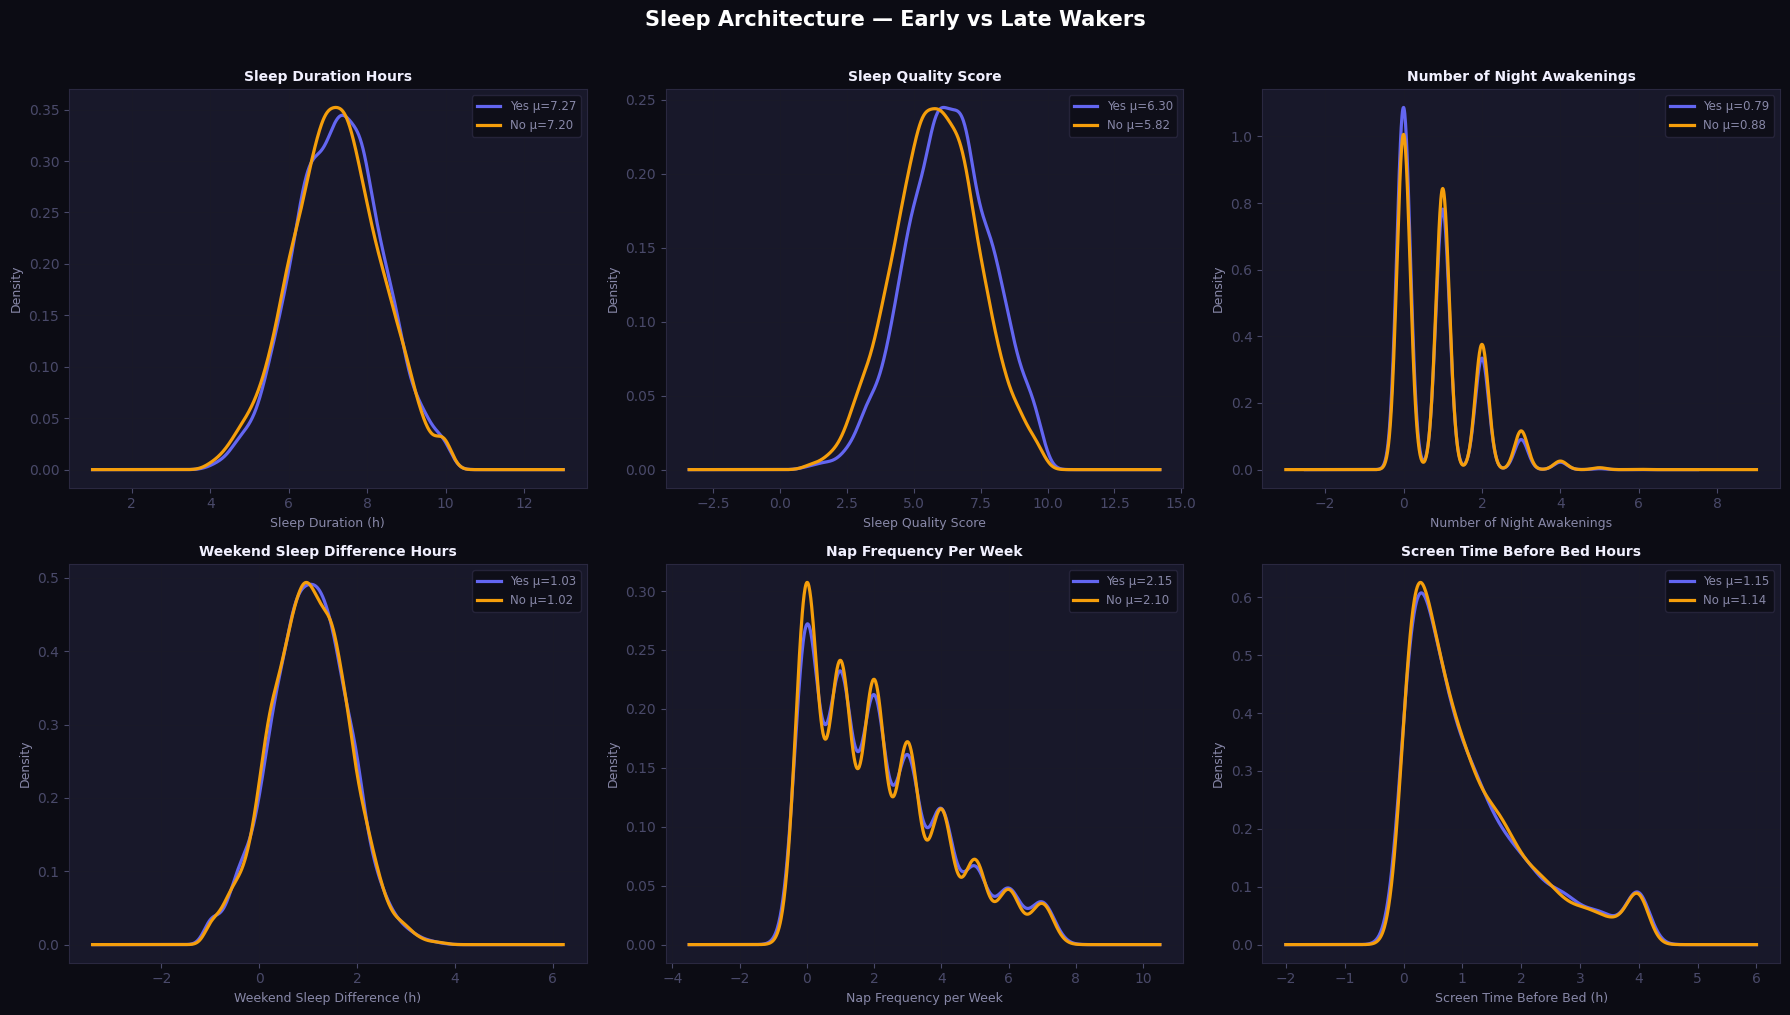

In [6]:
sleep_cols = ['Sleep_Duration_Hours','Sleep_Quality_Score','Number_of_Night_Awakenings',
              'Weekend_Sleep_Difference_Hours','Nap_Frequency_Per_Week','Screen_Time_Before_Bed_Hours']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Sleep Architecture — Early vs Late Wakers', fontsize=15,
             fontweight='bold', color='white', y=1.01)

for ax, col in zip(axes.flat, sleep_cols):
    for ew, color in EW_PAL.items():
        sub = df[df['Early_Waker']==ew][col].dropna()
        sub.plot.kde(ax=ax, color=color, lw=2.3, label=f'{ew} μ={sub.mean():.2f}')
    ax.set_xlabel(col.replace('_',' ').replace('Hours','(h)').replace('Per','per'), fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(col.replace('_',' '), fontweight='bold', fontsize=10)
    ax.legend(fontsize=8.5); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('03_sleep.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Exercise & Physical Activity <a id='5'></a>


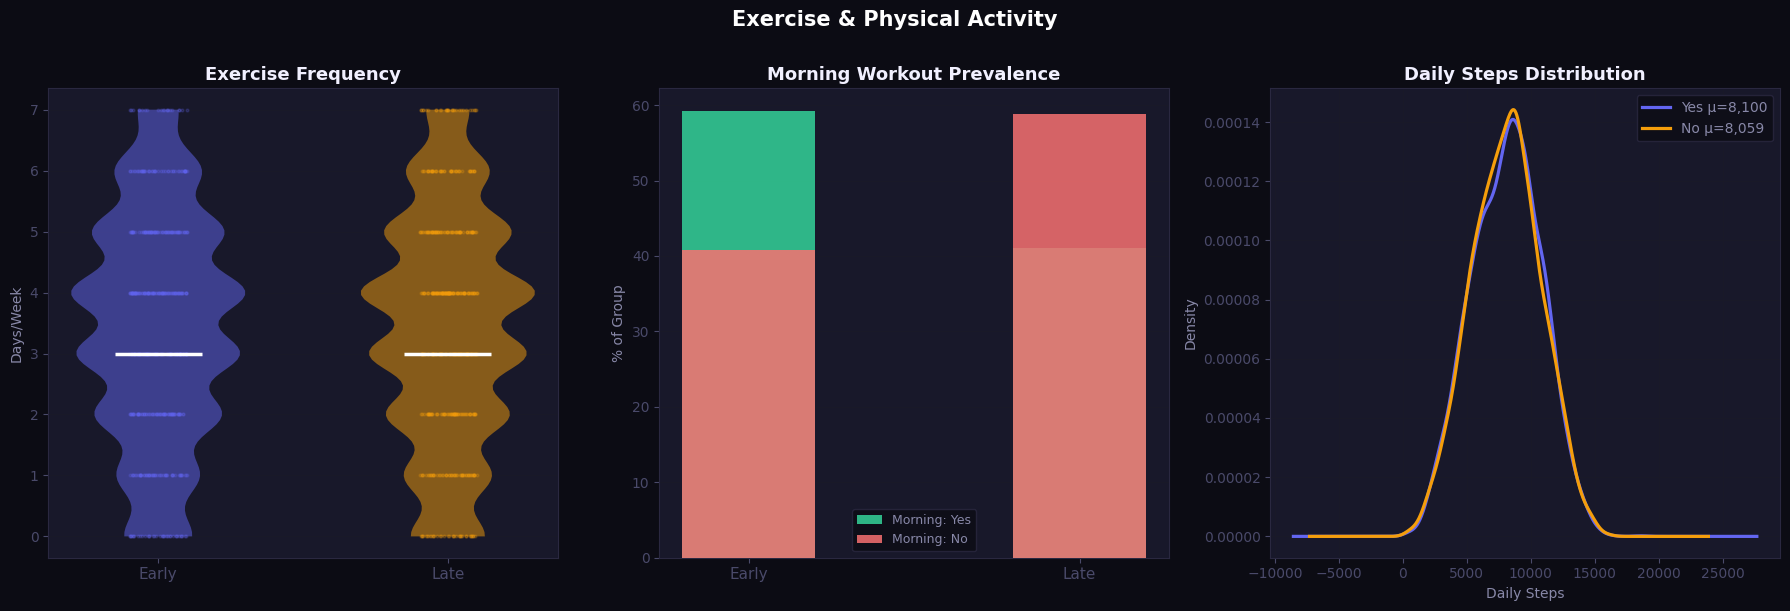

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Exercise & Physical Activity', fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Exercise frequency violin
ax = axes[0]
for i, (ew, color) in enumerate(EW_PAL.items()):
    data = df[df['Early_Waker']==ew]['Exercise_Frequency_Per_Week'].dropna()
    vp = ax.violinplot(data, positions=[i], widths=0.6, showmedians=True, showextrema=False)
    for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.5)
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
    jit = np.random.uniform(-0.1,0.1,min(len(data),500))
    ax.scatter(i+jit, data.sample(min(len(data),500), random_state=42), s=4, alpha=0.2, color=color)
ax.set_xticks([0,1]); ax.set_xticklabels(['Early','Late'], fontsize=11)
ax.set_ylabel('Days/Week'); ax.set_title('Exercise Frequency', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Morning workout % by early waker
ax = axes[1]
mw = df.groupby('Early_Waker')['Morning_Workout'].value_counts(normalize=True).unstack(fill_value=0)*100
for j, (mwo, color) in enumerate([('Yes',GRN),('No',RED)]):
    vals = [mw.loc[ew, mwo] if mwo in mw.columns and ew in mw.index else 0 for ew in ['Yes','No']]
    ax.bar([j*0 if k==0 else j*0+1 for j,k in enumerate([0,1])],
           vals, width=0.4, color=color, alpha=0.85, label=f'Morning: {mwo}', zorder=3)
ax.set_xticks([0,1]); ax.set_xticklabels(['Early','Late'], fontsize=11)
ax.set_ylabel('% of Group'); ax.set_title('Morning Workout Prevalence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Daily steps KDE
ax = axes[2]
for ew, color in EW_PAL.items():
    sub = df[df['Early_Waker']==ew]['Daily_Steps'].dropna()
    sub.plot.kde(ax=ax, color=color, lw=2.3, label=f'{ew} μ={sub.mean():,.0f}')
ax.set_xlabel('Daily Steps'); ax.set_ylabel('Density')
ax.set_title('Daily Steps Distribution', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('04_exercise.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Nutrition & Lifestyle Habits <a id='6'></a>


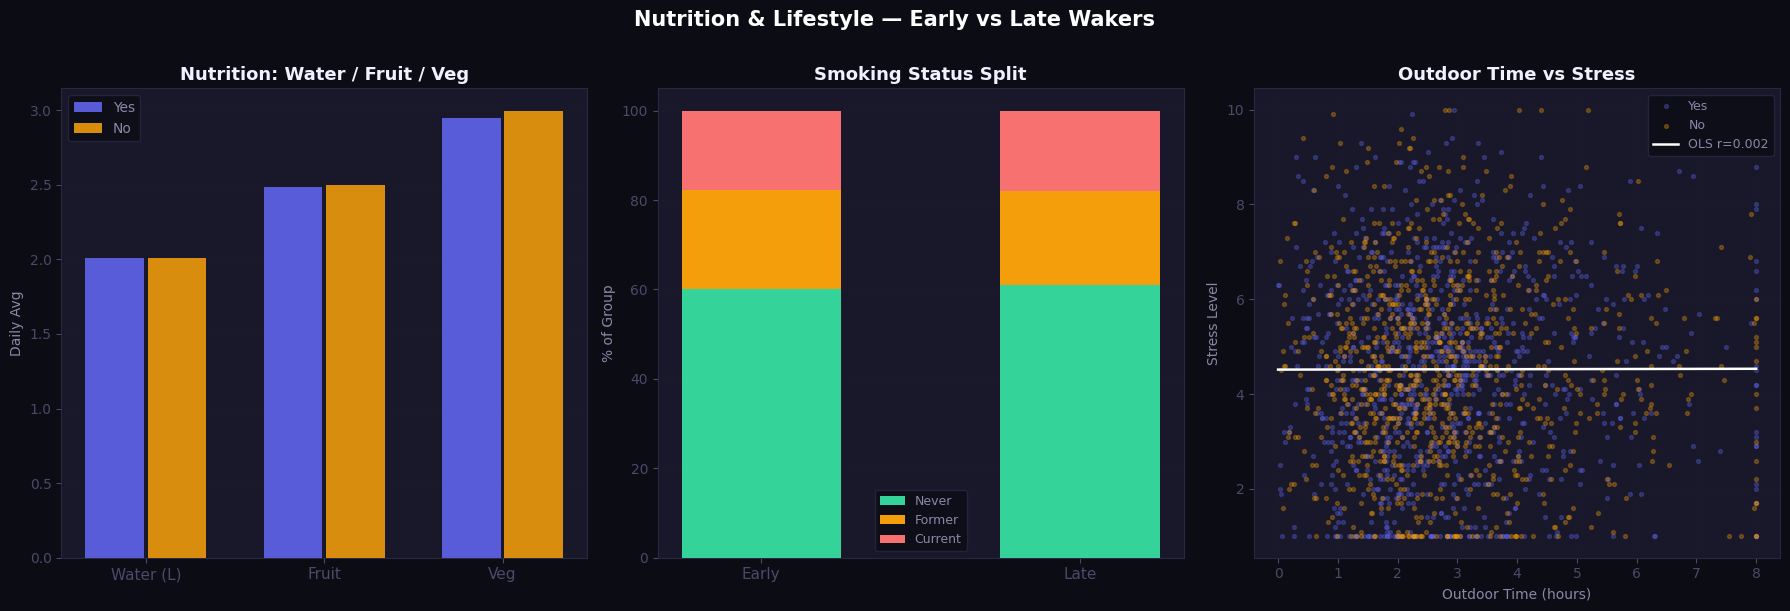

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Nutrition & Lifestyle — Early vs Late Wakers', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# 1. Nutrition grouped bar
ax = axes[0]
nut_cols = ['Water_Intake_Liters','Fruit_Intake_Per_Day','Vegetable_Intake_Per_Day']
nut_labels = ['Water (L)','Fruit','Veg']
x = np.arange(3)
for j, (ew, color) in enumerate(EW_PAL.items()):
    vals = [df[df['Early_Waker']==ew][c].mean() for c in nut_cols]
    ax.bar(x + (j-0.5)*0.35, vals, 0.33, color=color, alpha=0.88, label=ew, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(nut_labels, fontsize=11)
ax.set_ylabel('Daily Avg'); ax.set_title('Nutrition: Water / Fruit / Veg', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Smoking & alcohol stacked bar
ax = axes[1]
for k, (col, cats) in enumerate([('Smoking_Status',['Never','Former','Current']),
                                  ('Alcohol_Consumption',['None','Light','Moderate','Heavy'])]):
    pass
# Simpler: smoking status % by early waker
smk_colors = [GRN, AMB, RED]
smk_cats = ['Never','Former','Current']
bottoms2 = np.zeros(2)
for cat, color in zip(smk_cats, smk_colors):
    vals2 = [df[df['Early_Waker']==ew]['Smoking_Status'].value_counts(normalize=True).get(cat,0)*100
             for ew in ['Yes','No']]
    ax.bar([0,1], vals2, bottom=bottoms2, color=color, label=cat, width=0.5, zorder=3)
    bottoms2 += np.array(vals2)
ax.set_xticks([0,1]); ax.set_xticklabels(['Early','Late'], fontsize=11)
ax.set_ylabel('% of Group'); ax.set_title('Smoking Status Split', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Stress level + outdoor time scatter
ax = axes[2]
for ew, color in EW_PAL.items():
    sub = df[df['Early_Waker']==ew].sample(min(1000, len(df[df['Early_Waker']==ew])), random_state=42)
    ax.scatter(sub['Outdoor_Time_Hours'], sub['Stress_Level'],
               color=color, s=8, alpha=0.3, label=ew, zorder=3)
m, b, r, _, _ = stats.linregress(df['Outdoor_Time_Hours'], df['Stress_Level'])
xr = np.linspace(0, 8, 60)
ax.plot(xr, m*xr+b, color='white', lw=1.8, zorder=6, label=f'OLS r={r:.3f}')
ax.set_xlabel('Outdoor Time (hours)'); ax.set_ylabel('Stress Level')
ax.set_title('Outdoor Time vs Stress', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_nutrition.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Mental Health & Wellbeing <a id='7'></a>


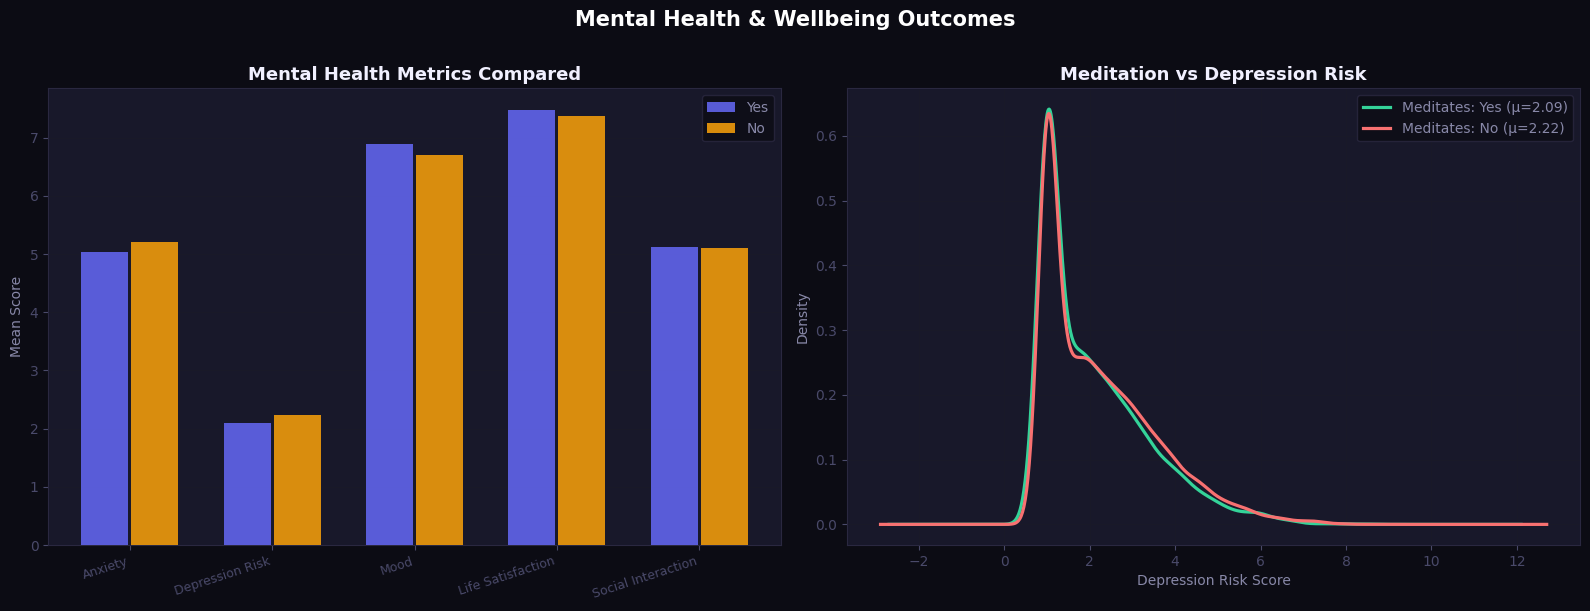

In [9]:
mental_cols = ['Anxiety_Score','Depression_Risk_Score','Mood_Score',
               'Life_Satisfaction_Score','Social_Interaction_Score']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Mental Health & Wellbeing Outcomes', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# 1. Spider/radar via normalized grouped bar (compact)
ax = axes[0]
x = np.arange(len(mental_cols))
labels = [c.replace('_Score','').replace('_',' ') for c in mental_cols]
for j, (ew, color) in enumerate(EW_PAL.items()):
    means = [df[df['Early_Waker']==ew][c].mean() for c in mental_cols]
    ax.bar(x + (j-0.5)*0.35, means, 0.33, color=color, alpha=0.88, label=ew, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=18, ha='right')
ax.set_ylabel('Mean Score'); ax.set_title('Mental Health Metrics Compared', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Meditation practice vs Depression Risk
ax = axes[1]
for med, color in [('Yes',GRN),('No',RED)]:
    sub = df[df['Meditation_Practice']==med]['Depression_Risk_Score'].dropna()
    sub.plot.kde(ax=ax, color=color, lw=2.3,
                 label=f'Meditates: {med} (μ={sub.mean():.2f})')
ax.set_xlabel('Depression Risk Score'); ax.set_ylabel('Density')
ax.set_title('Meditation vs Depression Risk', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('06_mental.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Biometrics & Clinical Markers <a id='8'></a>


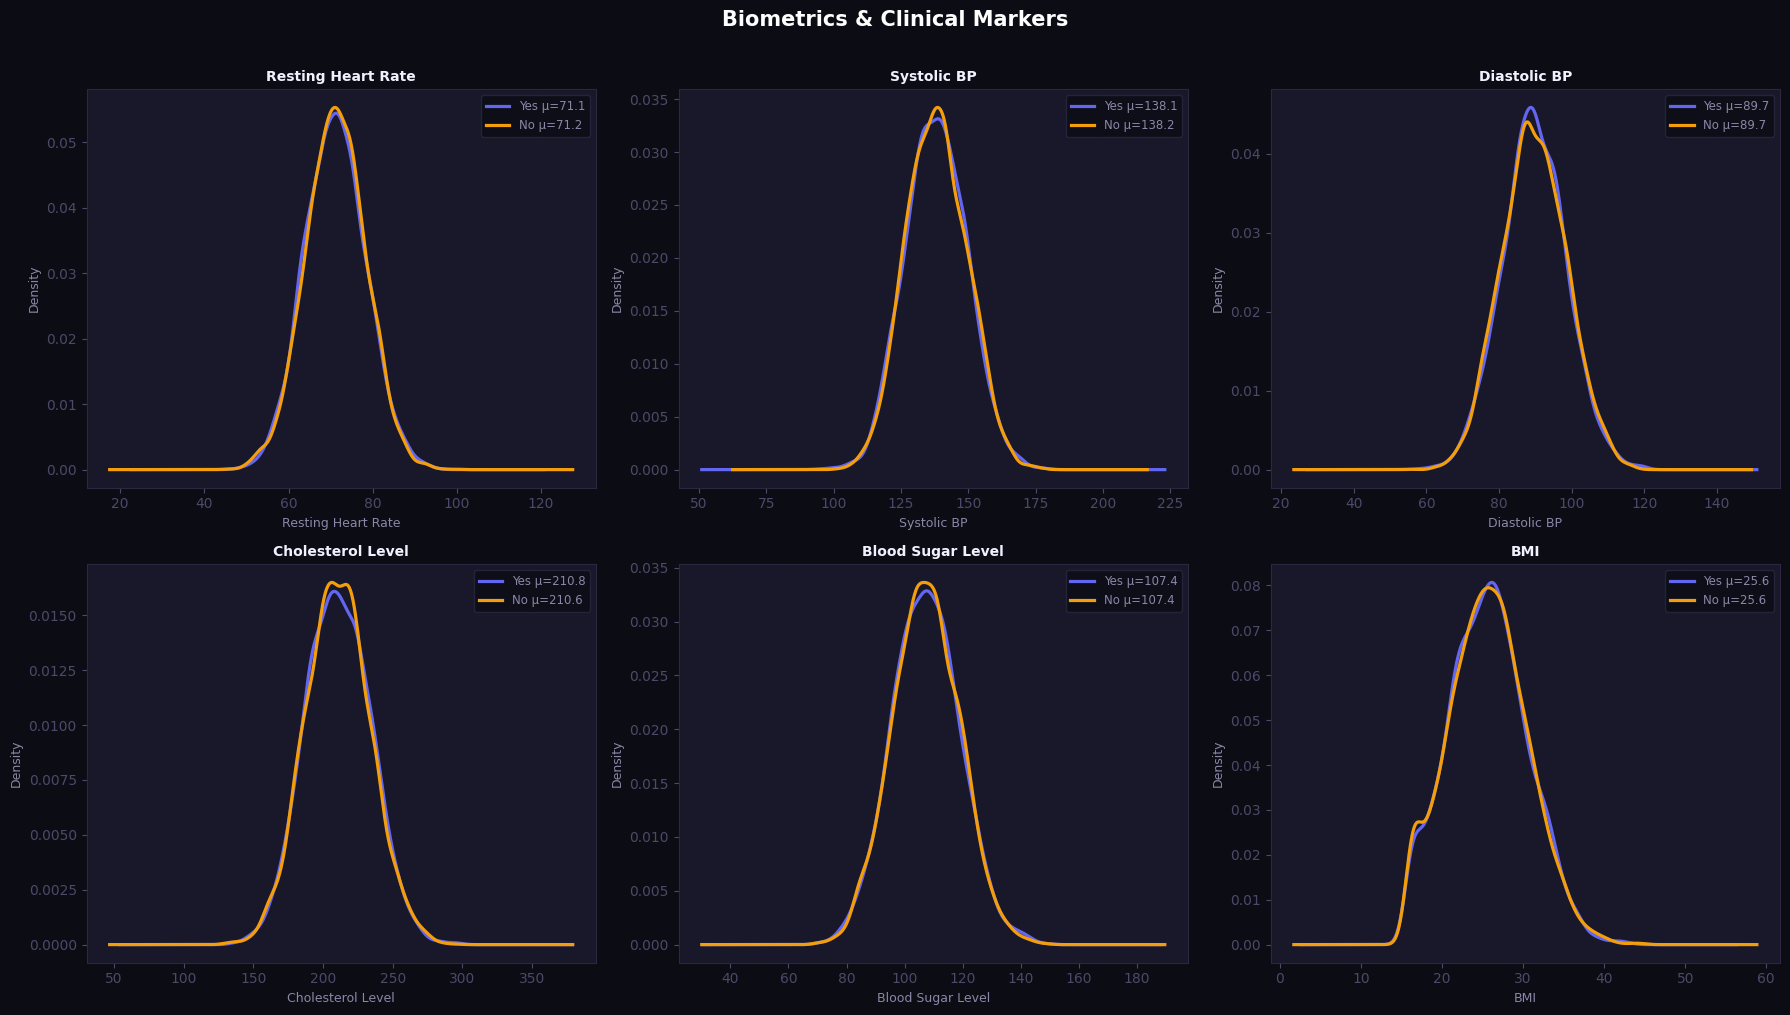

In [10]:
bio_cols = ['Resting_Heart_Rate','Systolic_BP','Diastolic_BP','Cholesterol_Level','Blood_Sugar_Level','BMI']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Biometrics & Clinical Markers', fontsize=15,
             fontweight='bold', color='white', y=1.01)

for ax, col in zip(axes.flat, bio_cols):
    for ew, color in EW_PAL.items():
        sub = df[df['Early_Waker']==ew][col].dropna()
        sub.plot.kde(ax=ax, color=color, lw=2.3, label=f'{ew} μ={sub.mean():.1f}')
    ax.set_xlabel(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(col.replace('_',' '), fontweight='bold', fontsize=10)
    ax.legend(fontsize=8.5); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('07_biometrics.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Correlation Heatmap <a id='9'></a>


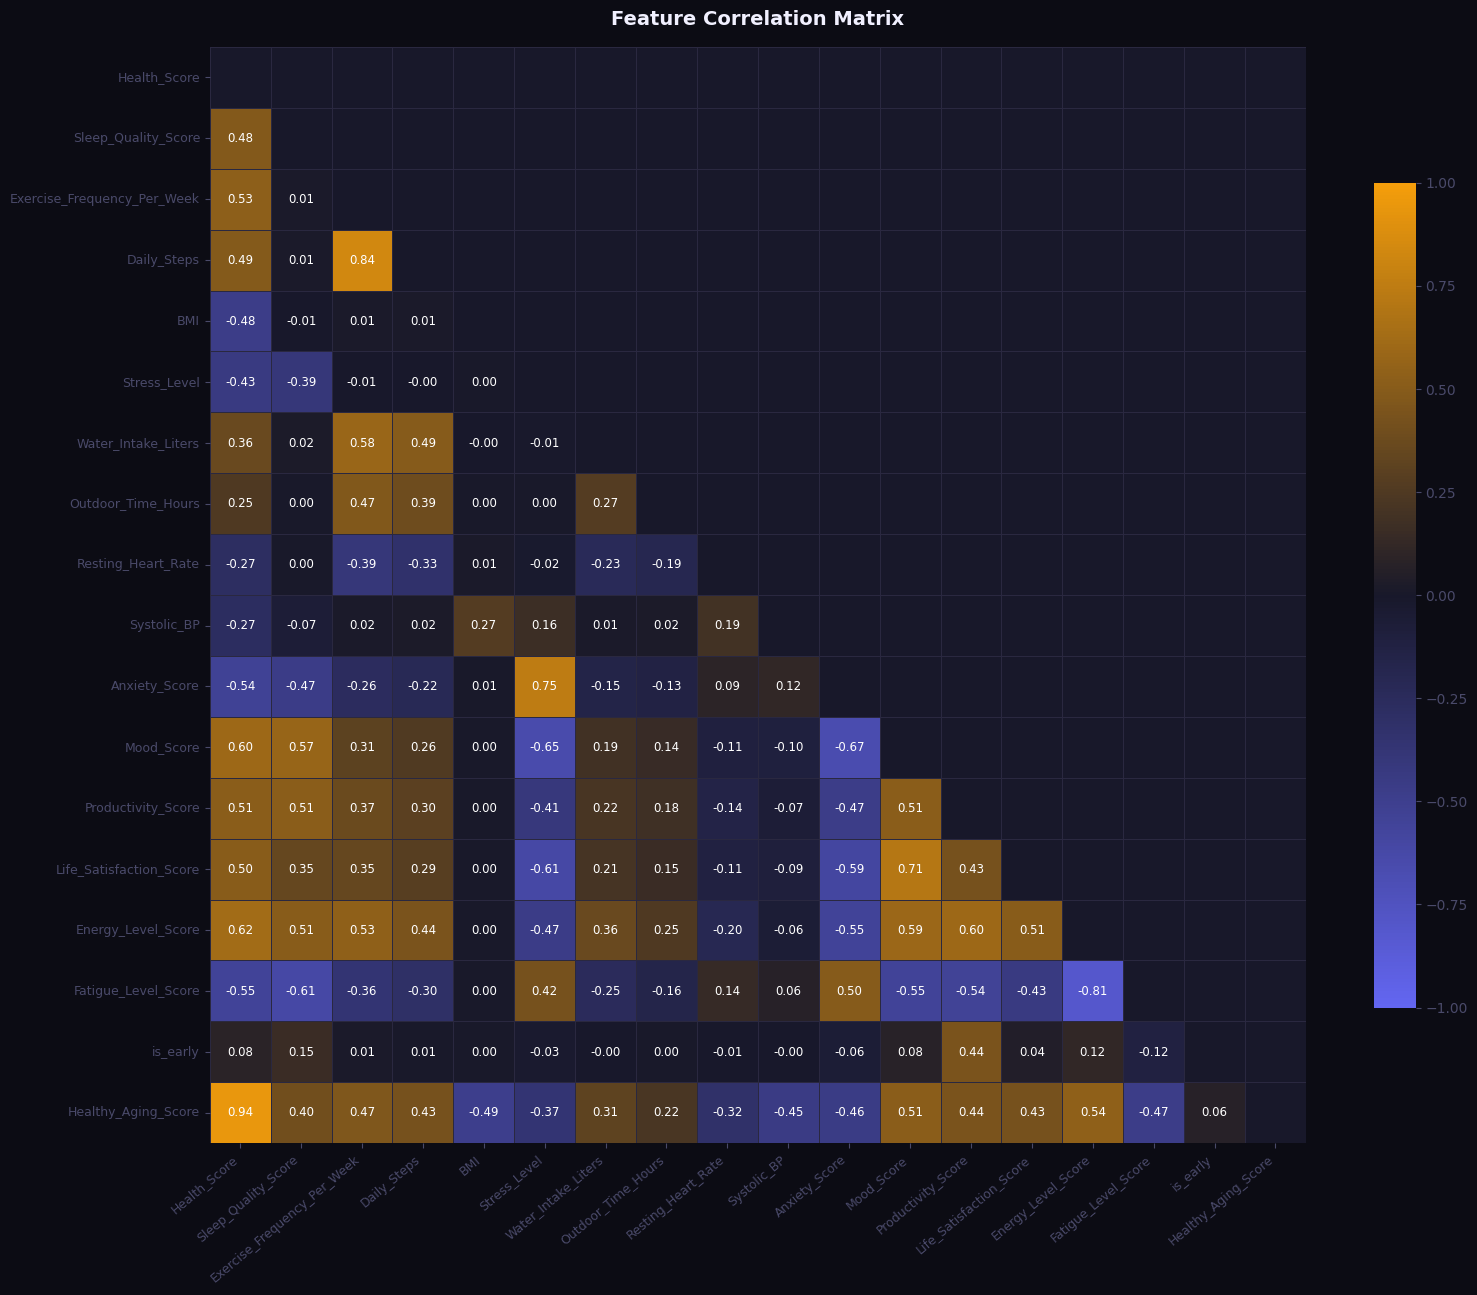

Top Health_Score correlates:
Healthy_Aging_Score            0.939
Energy_Level_Score             0.623
Mood_Score                     0.601
Fatigue_Level_Score           -0.550
Anxiety_Score                 -0.536
Exercise_Frequency_Per_Week    0.527
Productivity_Score             0.514
Life_Satisfaction_Score        0.500
Name: Health_Score, dtype: float64


In [11]:
num_cols = ['Health_Score','Sleep_Quality_Score','Exercise_Frequency_Per_Week',
            'Daily_Steps','BMI','Stress_Level','Water_Intake_Liters',
            'Outdoor_Time_Hours','Resting_Heart_Rate','Systolic_BP',
            'Anxiety_Score','Mood_Score','Productivity_Score','Life_Satisfaction_Score',
            'Energy_Level_Score','Fatigue_Level_Score','is_early','Healthy_Aging_Score']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_A, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor=GRID,
            annot_kws={'size':8.5,'color':'white'},
            cbar_kws={'shrink':0.75}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('08_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top Health_Score correlates:')
print(corr['Health_Score'].drop('Health_Score').sort_values(key=abs, ascending=False).round(3).head(8))


## 10. ML Classifier — Predicting Health Score Tier <a id='10'></a>


=== Random Forest — Health Tier Classifier ===
              precision    recall  f1-score   support

       Elite       0.85      0.59      0.70       264
        High       0.70      0.76      0.73       707
         Low       0.80      0.63      0.70       258
         Mid       0.72      0.80      0.76       771

    accuracy                           0.73      2000
   macro avg       0.77      0.69      0.72      2000
weighted avg       0.74      0.73      0.73      2000



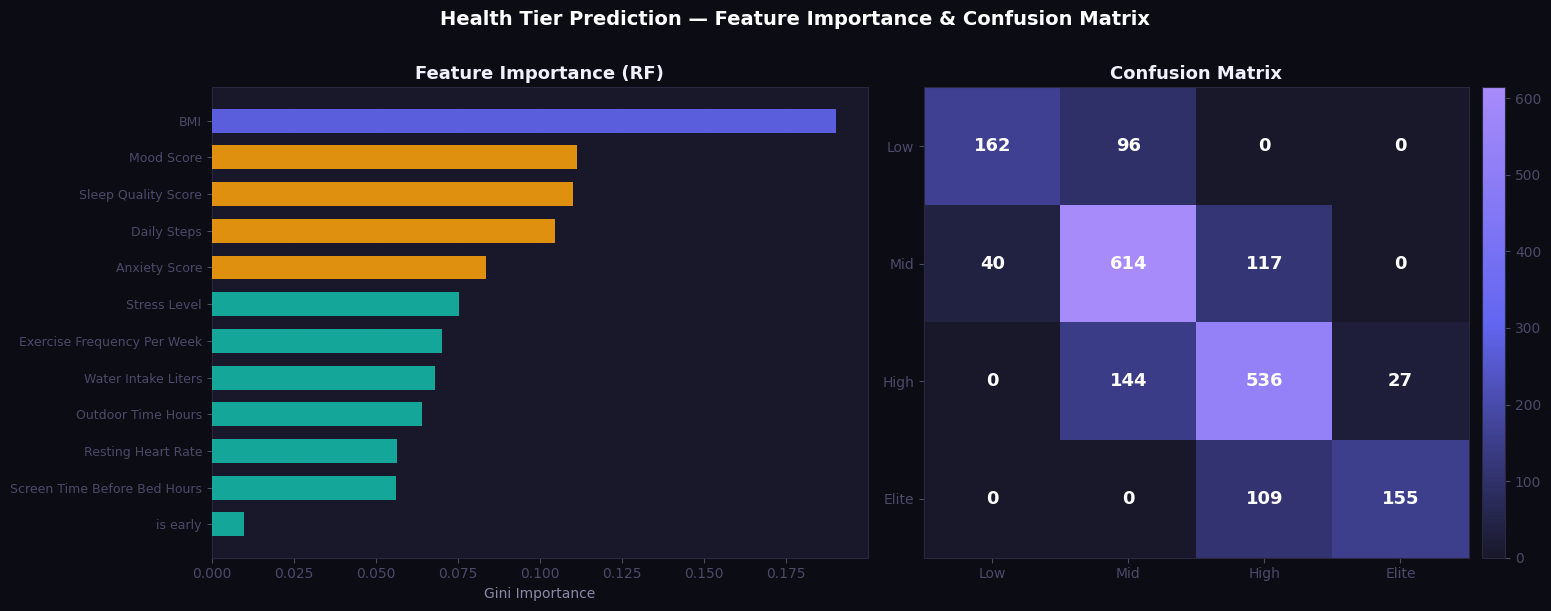

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

feat_cols = ['is_early','Sleep_Quality_Score','Exercise_Frequency_Per_Week',
             'Daily_Steps','BMI','Stress_Level','Water_Intake_Liters',
             'Outdoor_Time_Hours','Screen_Time_Before_Bed_Hours',
             'Resting_Heart_Rate','Anxiety_Score','Mood_Score']
X = df[feat_cols].dropna()
y = df.loc[X.index, 'Health_Tier'].dropna()
X = X.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
print('=== Random Forest — Health Tier Classifier ===')
print(classification_report(y_test, preds))

# Feature importance + confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Health Tier Prediction — Feature Importance & Confusion Matrix',
             fontsize=14, fontweight='bold', color='white', y=1.01)

ax = axes[0]
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
colors_fi = [IND if v==imp.max() else (AMB if v>imp.mean() else TEAL) for v in imp.values]
ax.barh(range(len(imp)), imp.values, color=colors_fi, height=0.65, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(imp))); ax.set_yticklabels([f.replace('_',' ') for f in imp.index], fontsize=9)
ax.set_xlabel('Gini Importance'); ax.set_title('Feature Importance (RF)', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

ax = axes[1]
cm = confusion_matrix(y_test, preds, labels=['Low','Mid','High','Elite'])
im = ax.imshow(cm, cmap=CMAP_I, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(['Low','Mid','High','Elite'], fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(['Low','Mid','High','Elite'], fontsize=10)
ax.set_title('Confusion Matrix', fontweight='bold')
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=13, fontweight='bold', color='white')
plt.colorbar(im, ax=ax, pad=0.02)
plt.tight_layout()
plt.savefig('09_ml.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Key Takeaways <a id='11'></a>


<div style="background:#0c0c14;border-radius:12px;padding:26px 32px;font-family:'Segoe UI',sans-serif;border:1px solid #2a2840;">
  <div style="height:3px;background:linear-gradient(90deg,#4f46e5,#f59e0b,#34d399,#f87171);border-radius:2px;margin-bottom:22px;"></div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
    <div style="background:#18182a;border-radius:8px;padding:14px 18px;border-left:3px solid #6366f1;">
      <div style="color:#6366f1;font-size:0.68rem;letter-spacing:2px;margin-bottom:8px;">EARLY WAKING ADVANTAGE</div>
      <ul style="color:#6b6b8a;margin:0;padding-left:16px;line-height:1.85;font-size:0.82rem;">
        <li>Early wakers score <strong style='color:#f1f0ff'>+1.98 Health Score</strong> on average (75.4 vs 73.4)</li>
        <li>Productivity gap is the largest: <strong style='color:#f1f0ff'>+1.02 points</strong> for early wakers</li>
        <li>Fatigue is 12.5% lower (2.89 vs 3.29) — less daytime tiredness</li>
        <li>36.8% of early wakers reach 'Excellent' wellness vs only 30.6% of late wakers</li>
      </ul>
    </div>
    <div style="background:#18182a;border-radius:8px;padding:14px 18px;border-left:3px solid #f59e0b;">
      <div style="color:#f59e0b;font-size:0.68rem;letter-spacing:2px;margin-bottom:8px;">STRONGEST HEALTH DRIVERS</div>
      <ul style="color:#6b6b8a;margin:0;padding-left:16px;line-height:1.85;font-size:0.82rem;">
        <li>Exercise frequency: <strong style='color:#f1f0ff'>r = 0.527</strong> — the #1 correlate of Health Score</li>
        <li>Daily steps (r = 0.490) and Sleep Quality (r = 0.480) follow closely</li>
        <li>BMI is negatively correlated (r = −0.475) — weight management is critical</li>
        <li>Sitting hours has near-zero correlation (r = −0.013) — movement quality beats quantity</li>
      </ul>
    </div>
    <div style="background:#18182a;border-radius:8px;padding:14px 18px;border-left:3px solid #34d399;">
      <div style="color:#34d399;font-size:0.68rem;letter-spacing:2px;margin-bottom:8px;">SLEEP & LIFESTYLE</div>
      <ul style="color:#6b6b8a;margin:0;padding-left:16px;line-height:1.85;font-size:0.82rem;">
        <li>Average 7.23h sleep — early wakers maintain similar total duration to late wakers</li>
        <li>Early wakers have higher Sleep Quality Score (6.30 vs 5.82) despite earlier bedtimes</li>
        <li>Meditation practice is strongly linked to lower depression risk scores</li>
        <li>Outdoor time negatively correlates with stress — even modest exposure helps</li>
      </ul>
    </div>
    <div style="background:#18182a;border-radius:8px;padding:14px 18px;border-left:3px solid #f87171;">
      <div style="color:#f87171;font-size:0.68rem;letter-spacing:2px;margin-bottom:8px;">ML & LIMITATIONS</div>
      <ul style="color:#6b6b8a;margin:0;padding-left:16px;line-height:1.85;font-size:0.82rem;">
        <li>Random Forest classifies Health Tier (4-class) — Sleep Quality & Exercise dominate importance</li>
        <li>Early_Waker flag has moderate importance — it's a signal, not the cause</li>
        <li>Dataset is synthetic: correlations may be stronger than real-world populations</li>
        <li>Causality cannot be established — healthy people may simply wake earlier, not vice versa</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:12px;text-align:right;color:#1e1e30;font-size:0.68rem;font-family:monospace;">Author: Muhammad Aamir · 10,000 individuals · 63 features · Kaggle Notebook</div>
</div>
